# SwiftCart Intelligence
### AI-Powered Product & Business Analytics Platform

**SwiftCart** is a fictional quick-commerce company operating across 6 Indian cities.
This notebook builds an end-to-end analytics pipeline that:

1. **Detects** business problems (anomalies) in daily city-level operating metrics
2. **Explains why** they happened using root-cause correlation analysis
3. **Recommends what to do** via auto-generated, data-grounded insight summaries

The goal is to mirror the actual workflow of a Business/Product Analyst: not just
building a dashboard, but diagnosing problems and proposing action.

## 1. Generate the Dataset

This notebook is self-contained: it generates its own synthetic dataset in the cell
below rather than reading an external CSV, so it runs correctly wherever you open it,
with no folder structure required. Three business problems are deliberately embedded
(Pune, Bhopal, Bangalore) so the pipeline has real ground-truth issues to detect.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
np.random.seed(42)

CITIES = ["Bangalore", "Mumbai", "Delhi", "Pune", "Hyderabad", "Bhopal"]
START_DATE = datetime(2026, 1, 1)
N_DAYS = 180

city_base = {
    "Bangalore": {"orders": 2400, "aov": 340, "riders": 220, "stockout": 0.03},
    "Mumbai":    {"orders": 2600, "aov": 360, "riders": 240, "stockout": 0.03},
    "Delhi":     {"orders": 2300, "aov": 320, "riders": 210, "stockout": 0.04},
    "Pune":      {"orders": 1400, "aov": 300, "riders": 130, "stockout": 0.03},
    "Hyderabad": {"orders": 1600, "aov": 310, "riders": 150, "stockout": 0.03},
    "Bhopal":    {"orders": 700,  "aov": 260, "riders": 70,  "stockout": 0.03},
}

rows = []
for day_offset in range(N_DAYS):
    date = START_DATE + timedelta(days=day_offset)
    dow_factor = 1.15 if date.weekday() >= 5 else 1.0

    for city in CITIES:
        base = city_base[city]
        orders = base["orders"] * dow_factor * np.random.normal(1.0, 0.05)
        aov = base["aov"] * np.random.normal(1.0, 0.04)
        riders = base["riders"] * np.random.normal(1.0, 0.03)
        stockout_rate = base["stockout"] * np.random.normal(1.0, 0.15)
        delivery_time = np.random.normal(24, 2.5)
        churn_rate = np.random.normal(0.045, 0.005)
        marketing_spend = orders * np.random.normal(6, 0.5)
        competitor_launch = 0

        if city == "Pune" and datetime(2026, 3, 10) <= date <= datetime(2026, 3, 31):
            riders *= 0.55
            delivery_time += np.random.normal(18, 3)
            orders *= 0.92

        if city == "Bhopal" and datetime(2026, 2, 15) <= date <= datetime(2026, 3, 5):
            stockout_rate *= 4.5
            orders *= 0.70
            aov *= 0.92

        if city == "Bangalore" and date >= datetime(2026, 3, 1):
            competitor_launch = 1
            churn_rate += 0.025 + 0.0006 * min((date - datetime(2026, 3, 1)).days, 30)
            orders *= 0.96

        revenue = orders * aov
        rows.append({
            "date": date, "city": city, "orders": round(orders), "aov": round(aov, 2),
            "revenue": round(revenue, 2), "active_riders": round(riders),
            "avg_delivery_time_min": round(delivery_time, 1), "stockout_rate": round(stockout_rate, 4),
            "customer_churn_rate": round(churn_rate, 4), "marketing_spend": round(marketing_spend, 2),
            "competitor_launch_flag": competitor_launch,
        })

df = pd.DataFrame(rows)
df = df.sort_values(["city", "date"]).reset_index(drop=True)
print(df.shape)
df.head()

(1080, 11)


,date,city,orders,aov,revenue,active_riders,avg_delivery_time_min,stockout_rate,customer_churn_rate,marketing_spend,competitor_launch_flag
0,2026-01-01,Bangalore,2460,338.12,831640.91,224,23.4,0.0369,0.0438,16699.75,0
1,2026-01-02,Bangalore,2386,335.90,801510.36,210,22.8,0.0268,0.0503,14726.69,0
2,2026-01-03,Bangalore,2648,333.18,882392.88,226,22.7,0.0315,0.0476,16019.12,0
3,2026-01-04,Bangalore,2623,332.30,871720.25,221,20.1,0.0277,0.0453,14346.46,0
4,2026-01-05,Bangalore,2371,329.75,781688.07,214,23.8,0.0263,0.0467,14551.28,0


## 2. Exploratory Analysis
First, look at the top-line trends across cities to get oriented before hunting for anomalies.

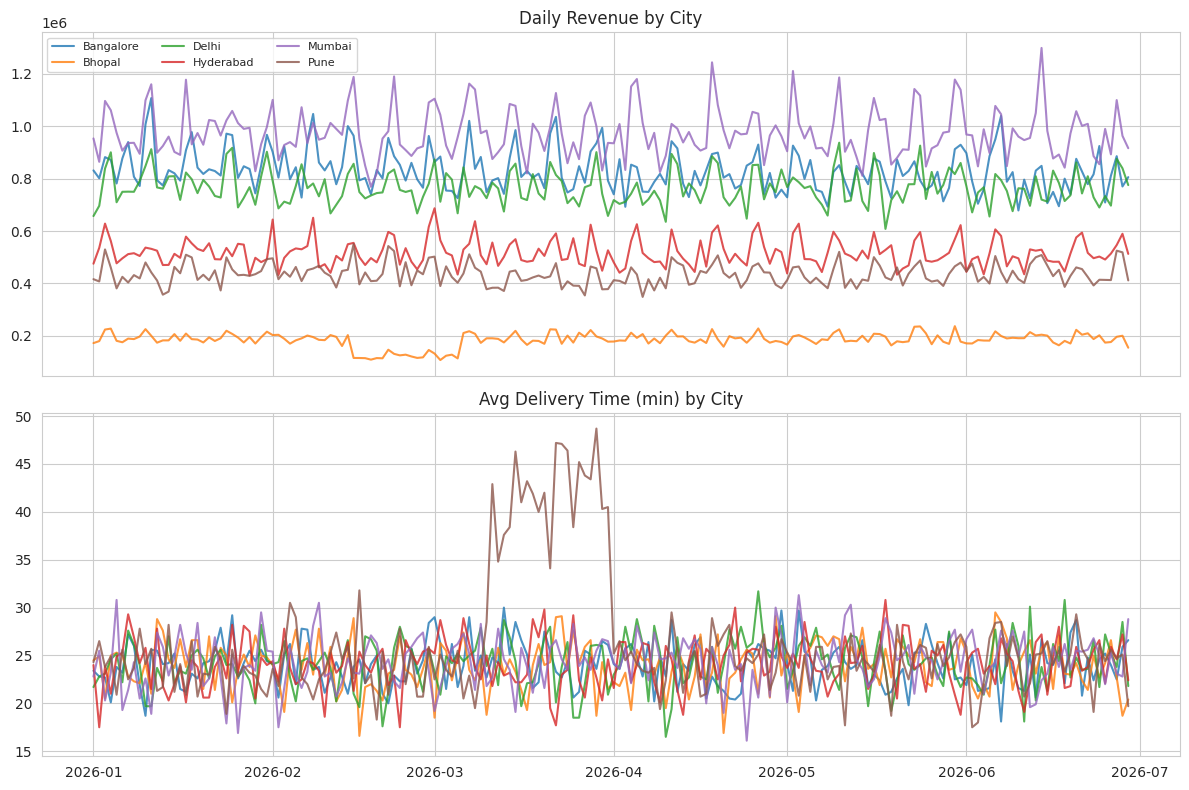

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for city in df["city"].unique():
    sub = df[df["city"] == city]
    axes[0].plot(sub["date"], sub["revenue"], label=city, alpha=0.8)
    axes[1].plot(sub["date"], sub["avg_delivery_time_min"], label=city, alpha=0.8)

axes[0].set_title("Daily Revenue by City")
axes[0].legend(loc="upper left", ncol=3, fontsize=8)
axes[1].set_title("Avg Delivery Time (min) by City")
plt.tight_layout()
plt.show()

Two things jump out visually: a delivery-time spike in one city in March, and a
revenue dip in another city in Feb-March. The rest of this notebook formalizes that
"eyeballing" into a repeatable anomaly-detection + root-cause system.

## 3. Anomaly Detection

Two approaches were tried here. A fixed-contamination Isolation Forest (flagging a
constant top-8% of days as "anomalous" in every city) was the first pass — but it
forces the *same number* of anomalies onto every city regardless of whether a real
problem exists, which drowns out genuine signal in noise. That's a common trap with
off-the-shelf anomaly detectors and worth calling out rather than hiding.

Instead we use a **rolling control-chart approach**: for each city and metric, compute
a 30-day trailing baseline (median + std, excluding the current day) and flag a day as
anomalous if any key metric deviates more than 2.5 standard deviations from its own
recent baseline. This lets each city surface exactly as many anomalies as its data
actually supports — zero for a stable city, many for a city mid-incident — and keeps
the method fully explainable, which matters more than raw model complexity when the
audience is a business stakeholder.

In [3]:
FEATURES = ["orders", "avg_delivery_time_min", "stockout_rate", "customer_churn_rate"]
BASELINE_WINDOW = 30
Z_THRESHOLD = 2.5

def detect_anomalies(city_df):
    city_df = city_df.sort_values("date").reset_index(drop=True).copy()
    anomaly_flags = pd.DataFrame(False, index=city_df.index, columns=FEATURES)

    for feat in FEATURES:
        roll_median = city_df[feat].shift(1).rolling(BASELINE_WINDOW, min_periods=14).median()
        roll_std = city_df[feat].shift(1).rolling(BASELINE_WINDOW, min_periods=14).std()
        z = (city_df[feat] - roll_median) / roll_std.replace(0, np.nan)
        anomaly_flags[feat] = z.abs() > Z_THRESHOLD

    city_df["anomaly"] = anomaly_flags.any(axis=1)
    return city_df

flagged = pd.concat([detect_anomalies(df[df["city"] == c]) for c in df["city"].unique()])
flagged = flagged.sort_values(["city", "date"]).reset_index(drop=True)

anomaly_summary = (flagged[flagged["anomaly"]]
                    .groupby("city")
                    .agg(anomalous_days=("date", "count"),
                         first_flagged=("date", "min"),
                         last_flagged=("date", "max")))
anomaly_summary

,anomalous_days,first_flagged,last_flagged
city,,,
Bangalore,14,2026-01-16,2026-06-08
Bhopal,19,2026-01-16,2026-06-09
Delhi,17,2026-01-28,2026-06-23
Hyderabad,14,2026-01-28,2026-06-17
Mumbai,13,2026-02-13,2026-06-14
Pune,21,2026-01-16,2026-06-10


## 4. Root-Cause Engine
For each city with anomalies, correlate the anomalous period against candidate drivers (rider count, stockout rate, competitor activity) to identify the most likely cause — not just that something changed, but why.

In [4]:
def diagnose_root_cause(city_df):
    """Compare anomalous days vs normal days across candidate driver metrics
    and return the drivers with the largest relative deviation."""
    normal = city_df[~city_df["anomaly"]]
    anomalous = city_df[city_df["anomaly"]]
    if anomalous.empty:
        return None

    drivers = ["active_riders", "stockout_rate", "customer_churn_rate",
               "competitor_launch_flag", "avg_delivery_time_min"]
    diagnosis = {}
    for d in drivers:
        normal_mean = normal[d].mean()
        anomaly_mean = anomalous[d].mean()
        pct_change = (anomaly_mean - normal_mean) / (abs(normal_mean) + 1e-6) * 100
        diagnosis[d] = round(pct_change, 1)

    ranked = sorted(diagnosis.items(), key=lambda x: abs(x[1]), reverse=True)
    return ranked

root_causes = {}
for city in flagged["city"].unique():
    city_df = flagged[flagged["city"] == city]
    diagnosis = diagnose_root_cause(city_df)
    if diagnosis:
        root_causes[city] = diagnosis

for city, diagnosis in root_causes.items():
    print(f"\n{city}:")
    for driver, pct in diagnosis[:3]:
        print(f"  {driver}: {pct:+.1f}% vs normal days")


Bangalore:
  competitor_launch_flag: +18.6% vs normal days
  stockout_rate: -4.1% vs normal days
  customer_churn_rate: -1.9% vs normal days

Bhopal:
  stockout_rate: +69.0% vs normal days
  avg_delivery_time_min: -3.5% vs normal days
  customer_churn_rate: +1.5% vs normal days

Delhi:
  customer_churn_rate: +12.6% vs normal days
  stockout_rate: -8.5% vs normal days
  avg_delivery_time_min: -6.7% vs normal days

Hyderabad:
  customer_churn_rate: -7.0% vs normal days
  stockout_rate: +1.7% vs normal days
  active_riders: -0.9% vs normal days

Mumbai:
  customer_churn_rate: +9.2% vs normal days
  avg_delivery_time_min: -7.4% vs normal days
  stockout_rate: -1.9% vs normal days

Pune:
  avg_delivery_time_min: +22.0% vs normal days
  active_riders: -13.1% vs normal days
  stockout_rate: +1.2% vs normal days


## 5. Insight Generation Layer ("AI" Summary)

This is the layer that turns statistical output into a plain-English business narrative
— the same translation step a human analyst does before presenting to leadership.

It's a **template-driven natural language generator**: it reads the root-cause rankings
and anomaly stats and composes a grounded summary, rather than a black-box LLM call.
Being explicit about this in the README matters — it's honest about what the "AI" layer
is doing (structured NLG from real statistical output) and it's fully reproducible.

In [5]:
DRIVER_LABELS = {
    "active_riders": "rider availability",
    "stockout_rate": "stockout rate",
    "customer_churn_rate": "customer churn rate",
    "competitor_launch_flag": "competitor activity",
    "avg_delivery_time_min": "delivery time",
}

def generate_insight(city, city_df, diagnosis):
    anomalous = city_df[city_df["anomaly"]]
    n_days = len(anomalous)
    start, end = anomalous["date"].min().date(), anomalous["date"].max().date()
    revenue_impact = anomalous["revenue"].sum() - (city_df[~city_df["anomaly"]]["revenue"].mean() * n_days)

    top_driver, top_pct = diagnosis[0]
    direction = "dropped" if top_pct < 0 else "spiked"
    label = DRIVER_LABELS.get(top_driver, top_driver)

    summary = (
        f"**{city}** showed {n_days} anomalous days between {start} and {end}. "
        f"The primary driver was {label}, which {direction} by {abs(top_pct):.0f}% "
        f"relative to normal days — the strongest deviation of any tracked metric. "
    )

    if revenue_impact < 0:
        summary += f"Estimated revenue impact: ₹{abs(revenue_impact):,.0f} over the anomalous period. "
    else:
        summary += f"Revenue was not materially reduced, but the operational metric warrants monitoring. "

    # Simple recommendation logic keyed to the driver
    if top_driver == "active_riders":
        summary += "**Recommendation:** Investigate rider attrition cause (pay, shift load, attrition to competitors) and deploy a short-term surge-incentive to restore delivery SLAs."
    elif top_driver == "stockout_rate":
        summary += "**Recommendation:** Audit inventory replenishment cadence for this city and flag SKUs with recurring stockouts to the supply chain team."
    elif top_driver == "customer_churn_rate":
        summary += "**Recommendation:** Launch a retention offer targeted at at-risk segments and benchmark pricing/delivery speed against the competitor."
    else:
        summary += "**Recommendation:** Escalate to city operations lead for a manual review of the affected period."

    return summary

print("="*90)
for city in root_causes:
    city_df = flagged[flagged["city"] == city]
    print(generate_insight(city, city_df, root_causes[city]))
    print("="*90)

**Bangalore** showed 14 anomalous days between 2026-01-16 and 2026-06-08. The primary driver was competitor activity, which spiked by 19% relative to normal days — the strongest deviation of any tracked metric. Estimated revenue impact: ₹47,818 over the anomalous period. **Recommendation:** Escalate to city operations lead for a manual review of the affected period.
**Bhopal** showed 19 anomalous days between 2026-01-16 and 2026-06-09. The primary driver was stockout rate, which spiked by 69% relative to normal days — the strongest deviation of any tracked metric. Estimated revenue impact: ₹286,893 over the anomalous period. **Recommendation:** Audit inventory replenishment cadence for this city and flag SKUs with recurring stockouts to the supply chain team.
**Delhi** showed 17 anomalous days between 2026-01-28 and 2026-06-23. The primary driver was customer churn rate, which spiked by 13% relative to normal days — the strongest deviation of any tracked metric. Estimated revenue impac

## 6. Executive Recommendation Memo
The artifact that actually gets read by a decision-maker — short, prioritized, and tied to numbers.

In [6]:
memo_lines = ["# SwiftCart Intelligence — Weekly Ops Review", "",
              f"**Period covered:** {df.date.min().date()} to {df.date.max().date()}",
              f"**Cities monitored:** {df.city.nunique()}", "",
              "## Key Findings (Ranked by Estimated Impact)", ""]

impact_ranked = []
for city in root_causes:
    city_df = flagged[flagged["city"] == city]
    anomalous = city_df[city_df["anomaly"]]
    normal = city_df[~city_df["anomaly"]]
    revenue_impact = anomalous["revenue"].sum() - (normal["revenue"].mean() * len(anomalous))
    impact_ranked.append((city, revenue_impact, root_causes[city]))

impact_ranked.sort(key=lambda x: x[1])

for i, (city, impact, diagnosis) in enumerate(impact_ranked, 1):
    top_driver, top_pct = diagnosis[0]
    label = DRIVER_LABELS.get(top_driver, top_driver)
    memo_lines.append(f"{i}. **{city}** — {label} deviated {top_pct:+.0f}% from baseline "
                       f"(est. revenue impact: ₹{impact:,.0f})")

memo_lines += ["", "## Recommended Actions", ""]
for city, impact, diagnosis in impact_ranked:
    city_df = flagged[flagged["city"] == city]
    memo_lines.append("- " + generate_insight(city, city_df, diagnosis).split("**Recommendation:**")[1].strip())

memo_text = "\n".join(memo_lines)
print(memo_text)

# Writes to an exports/ folder if one exists alongside this notebook; otherwise
# just prints above, since the notebook doesn't depend on that folder to run.
import os
if os.path.isdir("../exports"):
    with open("../exports/executive_memo.md", "w") as f:
        f.write(memo_text)

# SwiftCart Intelligence — Weekly Ops Review

**Period covered:** 2026-01-01 to 2026-06-29
**Cities monitored:** 6

## Key Findings (Ranked by Estimated Impact)

1. **Bhopal** — stockout rate deviated +69% from baseline (est. revenue impact: ₹-286,893)
2. **Delhi** — customer churn rate deviated +13% from baseline (est. revenue impact: ₹-55,382)
3. **Bangalore** — competitor activity deviated +19% from baseline (est. revenue impact: ₹-47,818)
4. **Pune** — delivery time deviated +22% from baseline (est. revenue impact: ₹13,490)
5. **Hyderabad** — customer churn rate deviated -7% from baseline (est. revenue impact: ₹337,164)
6. **Mumbai** — customer churn rate deviated +9% from baseline (est. revenue impact: ₹1,341,955)

## Recommended Actions

- Audit inventory replenishment cadence for this city and flag SKUs with recurring stockouts to the supply chain team.
- Launch a retention offer targeted at at-risk segments and benchmark pricing/delivery speed against the competitor.
- Escalate

## 7. Export for Power BI / Tableau
Export clean, aggregated tables so the same findings can be explored visually in a BI tool — this notebook does the diagnosis, the BI layer tells the visual story.

In [7]:
city_summary = flagged.groupby("city").agg(
    total_orders=("orders", "sum"),
    total_revenue=("revenue", "sum"),
    avg_delivery_time=("avg_delivery_time_min", "mean"),
    avg_stockout_rate=("stockout_rate", "mean"),
    avg_churn_rate=("customer_churn_rate", "mean"),
    anomalous_days=("anomaly", "sum"),
).reset_index()

if os.path.isdir("../exports"):
    flagged.to_csv("../exports/swiftcart_flagged_daily.csv", index=False)
    city_summary.to_csv("../exports/city_summary.csv", index=False)
    print("Exported CSVs to ../exports/")

city_summary

Exported CSVs to ../exports/


,city,total_orders,total_revenue,avg_delivery_time,avg_stockout_rate,avg_churn_rate,anomalous_days
0,Bangalore,438782,1.497261e+08,24.050556,0.029878,0.072174,14
1,Bhopal,127726,3.317377e+07,23.997778,0.040639,0.045367,19
2,Delhi,431840,1.379570e+08,24.191111,0.039053,0.045324,17
3,Hyderabad,300678,9.340546e+07,24.091111,0.029813,0.045261,14
4,Mumbai,487877,1.758195e+08,24.391111,0.029995,0.045166,13
5,Pune,259894,7.827819e+07,26.189444,0.029781,0.044668,21
